In [1]:
import numpy as np
dataset_filename = 'Ch1_affinity_dataset.txt'
x=np.loadtxt(dataset_filename)
#print(x)
print(x[0:5, :])
print(x[2:3, 3:5]) 

[[0. 0. 1. 1. 1.]
 [1. 1. 0. 1. 0.]
 [1. 0. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 1. 0. 0. 1.]]
[[1. 0.]]


In [2]:
features = ["bread","milk","cheese","apples","bananas"]
num_apples_purchased = 0
for i in range(x.shape[0]):
    if x[i, 3] == 1:
        num_apples_purchased += 1
print("Number of customers who purchased apples:", num_apples_purchased)

Number of customers who purchased apples: 36


In [3]:
num_bananas_purchased = 0
for i in range(x.shape[0]):
    if x[i, 4] == 1:
        num_bananas_purchased += 1
print("Number of customers who purchased bananas:", num_bananas_purchased)

Number of customers who purchased bananas: 59


In [4]:
num_bread_purchased = 0
for i in range(x.shape[0]):
    if x[i, 0] == 1:
        num_bread_purchased += 1
print("Number of customers who purchased bread:", num_bread_purchased)

num_milk_purchased = 0
for i in range(x.shape[0]):
    if x[i, 1] == 1:
        num_milk_purchased += 1
print("Number of customers who purchased milk:", num_milk_purchased)

num_cheese_purchased = 0
for i in range(x.shape[0]):
    if x[i, 2] == 1:
        num_cheese_purchased += 1
print("Number of customers who purchased cheese:", num_cheese_purchased)

Number of customers who purchased bread: 27
Number of customers who purchased milk: 46
Number of customers who purchased cheese: 41


In [5]:
#Only  consider the rule: if both apples and bananas purchased
rule_valid = 0
rule_invalid = 0
for sample in x:
    if sample[3] == 1:  # if apples purchased
        if sample[4] == 1:  # if bananas purchased
            rule_valid += 1
        else:
            rule_invalid += 1
print("{0} cases of rule being valid were discovered".format(rule_valid))
print("{0} cases of rule being invalid were discovered".format(rule_invalid))

21 cases of rule being valid were discovered
15 cases of rule being invalid were discovered


In [6]:
#Only  consider the rule: if both bread and milk purchased
rule_valid_count = 0
rule_invalid_count = 0
for sample in x:
    if sample[0] == 1:  # if bread purchased
        if sample[1] == 1:  # if milk purchased
            rule_valid_count += 1
        else:
            rule_invalid_count += 1
print("{0} cases of bread and milk being purchased together were discovered".format(rule_valid_count))
print("{0} cases of bread being purchased without milk were discovered".format(rule_invalid_count))

14 cases of bread and milk being purchased together were discovered
13 cases of bread being purchased without milk were discovered


In [7]:
#Only  consider the rule: if both milk and apples purchased
milk_apple_valid = 0
milk_apple_invalid = 0
for sample in x:
    if sample[1] == 1:  # if milk purchased
        if sample[3] == 1:  # if apples purchased
            milk_apple_valid += 1
        else:
            milk_apple_invalid += 1
print("{0} cases of milk and apples being purchased together were discovered".format(milk_apple_valid))
print("{0} cases of milk being purchased without apples were discovered".format(milk_apple_invalid))
print("{0} total cases of milk and apples".format(milk_apple_valid+milk_apple_invalid))

print("The support is {0} and the confidence is {1:.3f} ({2:.2f}%)".format(milk_apple_valid , milk_apple_valid / (milk_apple_valid + milk_apple_invalid), milk_apple_valid * 100 / (milk_apple_valid + milk_apple_invalid)))


9 cases of milk and apples being purchased together were discovered
37 cases of milk being purchased without apples were discovered
46 total cases of milk and apples
The support is 9 and the confidence is 0.196 (19.57%)


In [8]:
#HW
from sklearn.datasets import load_iris
dataset = load_iris()
data = dataset.data
target = dataset.target
headers = dataset.feature_names
labels = dataset.target_names

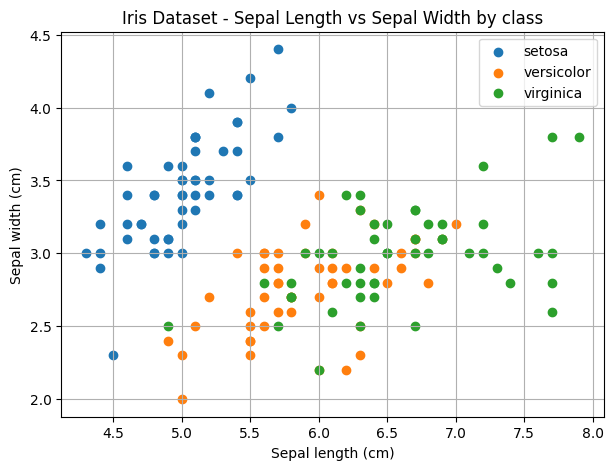

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for i,label in enumerate(labels):
    plt.scatter(data[target == i, 0], data[target == i, 1], label=labels[i])

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title('Iris Dataset - Sepal Length vs Sepal Width by class')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#OneR
from collections import defaultdict
from operator import itemgetter
def train_feature_value(X, y_true, feature_index, value):
    class_counts = defaultdict(int)
    for sample, y in zip(X, y_true):
        if sample[feature_index] == value:
            class_counts[y] += 1
    sorted_class_counts = sorted(class_counts.items(),
    key=itemgetter(1), reverse=True)
    most_frequent_class = sorted_class_counts[0][0]
    incorrect_predictions = [class_count for class_value, class_count
    in class_counts.items()
    if class_value != most_frequent_class]
    error = sum(incorrect_predictions)
    return most_frequent_class, error

def train_on_feature(X, y_true, feature_index):
    values = set(X[:,feature_index])
    predictors = {}
    errors = []
    for value in values:
        predictor, error = train_feature_value(X, y_true,
        feature_index, value)
        predictors[value] = predictor
        errors.append(error)
    total_error = sum(errors)
    return predictors, total_error

In [20]:
# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Discretize features
X_d = np.floor(X / np.ptp(X, axis=0) * 10)

# Train-test split
Xd_train, Xd_test, y_train, y_test = train_test_split(X_d, y, random_state=14)

# Train OneR
all_predictors = {}
errors = {}

for feature_index in range(Xd_train.shape[1]):
    predictors, total_error = train_on_feature(Xd_train, y_train, feature_index)
    all_predictors[feature_index] = predictors
    errors[feature_index] = total_error

best_feature, best_error = sorted(errors.items(), key=itemgetter(1))[0]
model = {'feature': best_feature, 'predictor': all_predictors[best_feature]}

# Predict function
def predict(X_test, model):
    variable = model['feature']
    predictor = model['predictor']
    y_predicted = np.array([predictor.get(int(sample[variable]), 0) for sample in X_test])
    return y_predicted

# Evaluate
y_predicted = predict(Xd_test, model)
accuracy = np.mean(y_predicted == y_test) * 100
print("The test accuracy is {:.1f}%".format(accuracy))

The test accuracy is 97.4%
